# CS3807 – Deep Learning Laboratory
# Experiment 5: Comprehensive Study of CNN Training, Regularization, Optimization,
# Hyperparameter Tuning, Transfer Learning and Cross-Validation

**Model:** MobileNetV2 (ImageNet pretrained)
**Dataset:** Oxford-IIIT Pet Dataset (37 breeds, cats & dogs)

This notebook is designed to run top-to-bottom in **Google Colab** and uses the
**entire Oxford-IIIT Pet dataset** (no subsetting) for every experiment, including
the 5-fold cross-validation stage. Every plot is displayed inline **and** saved as
a **600 DPI `.eps`** file in a local `plots/` folder (see `save_plot()` in the
setup cell) — download that folder at the end of the run to get all figures as
publication-quality vector/high-res files.

> **Runtime tip:** Runtime → Change runtime type → GPU (T4) before running.
> Because the full dataset (~7,349 images) is used throughout, and this notebook
> trains dozens of model variants (initializations, regularizers, optimizers,
> hyperparameter sweeps, transfer-learning cases, and 5-fold CV × several
> configurations), **total runtime can be long (well over an hour on a T4 GPU,
> much longer on CPU)**. You can reduce `EPOCHS_QUICK` in the config cell if you
> need a faster run, but all data splits always use the full dataset.
>
> This version also includes memory-safety fixes (GPU memory growth, explicit
> `reset_tf()`/`del model` cleanup between runs, and disk-cached preprocessing)
> to avoid the kernel crashes that long, memory-heavy notebooks can trigger.


## 0. Setup and Configuration

In [1]:

!pip install -q tensorflow-datasets scikit-learn pandas matplotlib seaborn


In [2]:

import os
import gc
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models, regularizers, optimizers, initializers
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support
import seaborn as sns

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs available:", gpus)

# Enable memory growth so TF doesn't pre-allocate all GPU memory up front --
# this, combined with the explicit cleanup helper below, avoids the
# out-of-memory kernel crashes that can occur when dozens of models are
# built/destroyed in a single long-running session.
for _gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(_gpu, True)
    except RuntimeError as e:
        print(e)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

def reset_tf():
    """Call between experiments to release Keras/TF graph state and force
    garbage collection. Prevents memory from accumulating across the many
    separate model-training runs in this notebook."""
    tf.keras.backend.clear_session()
    gc.collect()


TensorFlow version: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:

# ----------------------------- GLOBAL CONFIG --------------------------------
IMG_SIZE = 224
NUM_CLASSES = 37

# Every experiment in this notebook uses the FULL dataset for its train/val/test
# splits (see Section 3). EPOCHS_QUICK controls only how many epochs each
# comparative study trains for -- lower it if you need a faster run.
EPOCHS_QUICK = 7
BATCH_SIZE_DEFAULT = 32
LR_DEFAULT = 1e-3

AUTOTUNE = tf.data.AUTOTUNE

# ----------------------------- PLOT OUTPUT ----------------------------------
# Every plot in this notebook is saved as a 600 DPI .eps file in PLOT_DIR, in
# addition to being displayed inline.
PLOT_DIR = 'plots'
os.makedirs(PLOT_DIR, exist_ok=True)

def save_plot(fig_name, fig=None):
    """Saves the current (or given) matplotlib figure as a 600 DPI .eps file."""
    path = os.path.join(PLOT_DIR, f'{fig_name}.eps')
    (fig or plt).savefig(path, format='eps', dpi=600, bbox_inches='tight')
    print(f"Saved plot: {path}")


## 3. Dataset and Experimental Setup

We use the **entire Oxford-IIIT Pet Dataset** via `tensorflow_datasets`. Images are
resized to 224×224×3 and normalized using MobileNetV2's `preprocess_input` (scales
to [-1, 1]).

We build three **disjoint** splits covering the whole dataset (70% / 15% / 15%):
- **Train** — used for all training in every section (Sections 5–11).
- **Validation** — used for model selection / hyperparameter comparison.
- **Test** — held out and **never touched** until Section 12 (final evaluation).

No further subsetting is applied anywhere in this notebook — every experiment
trains and validates on the full train/validation pools.


In [4]:

# Load full dataset (combine the tfds train+test splits, then re-split ourselves
# so we control the exact train/val/test partition as required by the manual).
(ds_full,), ds_info = tfds.load(
    'oxford_iiit_pet',
    split=['train+test'],
    with_info=True,
    as_supervised=True
)

full_size = ds_info.splits['train'].num_examples + ds_info.splits['test'].num_examples
print("Total images in dataset:", full_size)
print("Number of classes:", ds_info.features['label'].num_classes)

ds_full = ds_full.shuffle(full_size, seed=SEED, reshuffle_each_iteration=False)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

I0000 00:00:1788098652.280008      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9


Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.KOGJLF_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.KOGJLF_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Total images in dataset: 7349
Number of classes: 37


In [5]:

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

def resize_only(image, label):
    # Lightweight version (uint8, no normalization) used only for materializing
    # arrays in-memory for K-Fold cross-validation (Section 11) -- keeps memory
    # usage 4x lower than storing normalized float32 images.
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(tf.clip_by_value(image, 0, 255), tf.uint8)
    return image, label

# Split proportions covering the WHOLE dataset: 70% train pool / 15% val pool / 15% test pool
n_train_pool = int(0.70 * full_size)
n_val_pool   = int(0.15 * full_size)
n_test_pool  = full_size - n_train_pool - n_val_pool

train_pool = ds_full.take(n_train_pool)
remaining  = ds_full.skip(n_train_pool)
val_pool   = remaining.take(n_val_pool)
test_pool  = remaining.skip(n_val_pool)

# Full datasets used for EVERY experiment in this notebook (Sections 5-12).
# We cache the (resize + normalize) result to LOCAL DISK rather than RAM:
#   - dozens of separate training runs below reuse these same pipelines, so
#     caching avoids re-decoding/resizing every image on every single run
#     (this was a major source of both slowdown and memory pressure), and
#   - disk caching keeps RAM usage low, unlike an in-memory .cache().
CACHE_DIR = '/content/tfcache' if os.path.isdir('/content') else '/tmp/tfcache'
os.makedirs(CACHE_DIR, exist_ok=True)

full_train_ds = train_pool.map(preprocess, num_parallel_calls=AUTOTUNE).cache(os.path.join(CACHE_DIR, 'train'))
full_val_ds   = val_pool.map(preprocess, num_parallel_calls=AUTOTUNE).cache(os.path.join(CACHE_DIR, 'val'))
full_test_ds  = test_pool.map(preprocess, num_parallel_calls=AUTOTUNE).cache(os.path.join(CACHE_DIR, 'test'))

def make_batches(ds, batch_size=BATCH_SIZE_DEFAULT, shuffle=False, shuffle_buf=2000):
    if shuffle:
        ds = ds.shuffle(shuffle_buf, seed=SEED)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

print(f"Full-dataset sizes -> train: {n_train_pool}  val: {n_val_pool}  test: {n_test_pool}")

# Warm the disk cache once up front (single full pass over each split) so that
# every subsequent .fit()/.evaluate() call below reads pre-processed images
# straight from disk instead of recomputing resize+normalize each time.
print("Warming disk cache (one-time pass over each split)...")
for _ in full_train_ds: pass
for _ in full_val_ds: pass
for _ in full_test_ds: pass
print("Cache warmed.")


Full-dataset sizes -> train: 5144  val: 1102  test: 1103
Warming disk cache (one-time pass over each split)...
Cache warmed.


Saved plot: plots/sample_dataset_images.eps


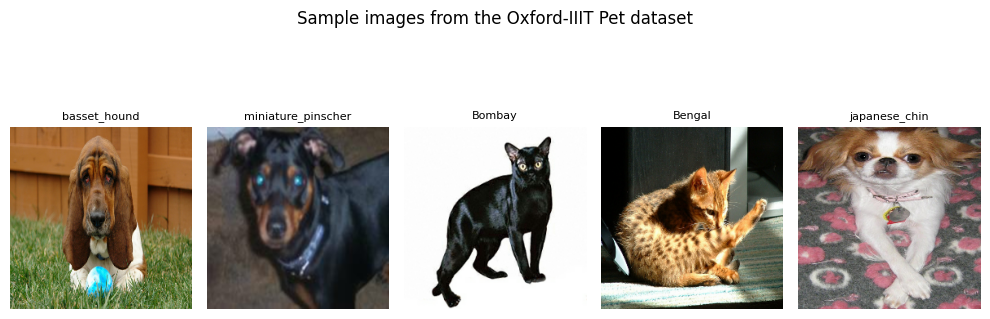

In [6]:

# Visual sanity check of a few samples
class_names = ds_info.features['label'].names

def denorm(img):
    img = (img + 1.0) * 127.5
    return np.clip(img.numpy(), 0, 255).astype('uint8')

plt.figure(figsize=(10, 4))
for i, (img, label) in enumerate(full_train_ds.take(5)):
    plt.subplot(1, 5, i + 1)
    plt.imshow(denorm(img))
    plt.title(class_names[label.numpy()], fontsize=8)
    plt.axis('off')
plt.suptitle("Sample images from the Oxford-IIIT Pet dataset")
plt.tight_layout()
save_plot('sample_dataset_images')
plt.show()


## 4. MobileNetV2 Architecture

MobileNetV2 uses depthwise-separable convolutions, inverted residual blocks with
linear bottlenecks, batch normalization and ReLU6 activations, making it lightweight
enough for CPU/laptop-scale experimentation while retaining strong ImageNet features.


In [7]:

base_preview = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet'
)
print("MobileNetV2 base: {} layers, {:,} parameters".format(
    len(base_preview.layers), base_preview.count_params()))
base_preview.summary()
del base_preview


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 base: 154 layers, 2,257,984 parameters


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)

## Common Model-Building Utility

All experiments below reuse a single helper, `build_model(...)`, which:
1. Loads MobileNetV2 pretrained on ImageNet as the feature extractor,
2. Freezes it fully (feature extraction) or partially (fine-tuning),
3. Attaches a new classification head whose initializer / regularization /
   dropout / batch-norm can be varied — exactly the controls needed for
   Sections 5–10.


In [8]:

def build_model(kernel_initializer='glorot_uniform',
                 l2_reg=0.0,
                 dropout_rate=0.0,
                 use_batchnorm=False,
                 unfreeze_last_n=0,
                 dense_units=128):
    """Builds a MobileNetV2-based classifier.

    kernel_initializer : initializer for the new Dense layers
                          ('zeros', 'random_normal', 'glorot_uniform', 'he_normal')
    l2_reg              : L2 weight-decay coefficient for the Dense layers
    dropout_rate         : dropout applied before the final classifier
    use_batchnorm        : whether to add a BatchNormalization layer in the head
    unfreeze_last_n       : number of trailing base-model layers to unfreeze
                          (0 = pure feature extraction / frozen base)
    """
    base = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet'
    )
    base.trainable = unfreeze_last_n > 0
    if unfreeze_last_n > 0:
        for layer in base.layers[:-unfreeze_last_n]:
            layer.trainable = False

    reg = regularizers.l2(l2_reg) if l2_reg > 0 else None

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False if unfreeze_last_n == 0 else None)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation='relu',
                      kernel_initializer=kernel_initializer,
                      kernel_regularizer=reg)(x)
    if use_batchnorm:
        x = layers.BatchNormalization()(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax',
                            kernel_initializer=kernel_initializer,
                            kernel_regularizer=reg)(x)

    model = models.Model(inputs, outputs)
    return model


def compile_and_train(model, optimizer, train_ds, val_ds, epochs=EPOCHS_QUICK, batch_size=BATCH_SIZE_DEFAULT, verbose=0):
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    train_b = make_batches(train_ds, batch_size=batch_size, shuffle=True)
    val_b = make_batches(val_ds, batch_size=batch_size)
    start = time.time()
    history = model.fit(train_b, validation_data=val_b, epochs=epochs, verbose=verbose)
    elapsed = time.time() - start
    return history, elapsed


## 5. Weight Initialization

We compare four initialization strategies for the new classifier head (the
pretrained MobileNetV2 base is frozen in all four runs, so any difference in
convergence is attributable to the initialization of the head):

- **Zero initialization**
- **Random (normal) initialization**
- **Xavier / Glorot initialization**
- **He initialization**


In [9]:

init_strategies = {
    'Zero': 'zeros',
    'Random Normal': initializers.RandomNormal(mean=0.0, stddev=0.05, seed=SEED),
    'Xavier/Glorot': 'glorot_uniform',
    'He': 'he_normal',
}

init_histories = {}
init_times = {}

for name, init in init_strategies.items():
    print(f"--- Training with {name} initialization ---")
    reset_tf()
    model = build_model(kernel_initializer=init)
    opt = optimizers.Adam(learning_rate=LR_DEFAULT)
    hist, elapsed = compile_and_train(model, opt, full_train_ds, full_val_ds)
    init_histories[name] = hist.history
    init_times[name] = elapsed
    print(f"{name}: final val_accuracy={hist.history['val_accuracy'][-1]:.4f}, time={elapsed:.1f}s")
    del model, opt, hist
    reset_tf()


--- Training with Zero initialization ---


I0000 00:00:1788098710.596150      92 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Zero: final val_accuracy=0.0136, time=71.3s
--- Training with Random Normal initialization ---
Random Normal: final val_accuracy=0.9102, time=60.7s
--- Training with Xavier/Glorot initialization ---
Xavier/Glorot: final val_accuracy=0.9093, time=60.7s
--- Training with He initialization ---
He: final val_accuracy=0.9065, time=60.7s


Saved plot: plots/plot1_weight_init_training_loss.eps


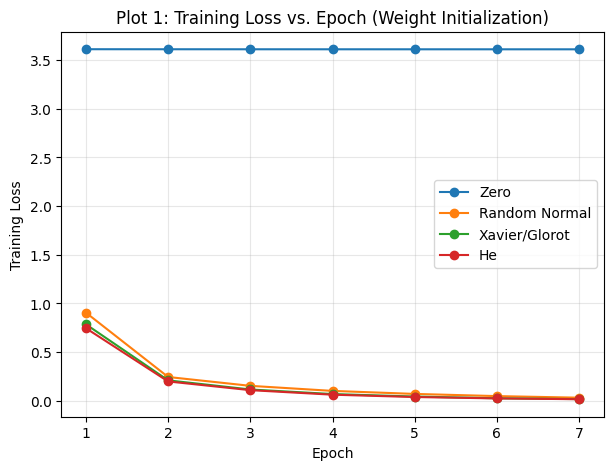

In [10]:

# Plot 1: Training Loss vs. Epoch
plt.figure(figsize=(7, 5))
for name, h in init_histories.items():
    plt.plot(range(1, len(h['loss']) + 1), h['loss'], marker='o', label=name)
plt.xlabel('Epoch'); plt.ylabel('Training Loss')
plt.title('Plot 1: Training Loss vs. Epoch (Weight Initialization)')
plt.legend(); plt.grid(True, alpha=0.3)
save_plot('plot1_weight_init_training_loss')
plt.show()


Saved plot: plots/plot2_weight_init_val_accuracy.eps


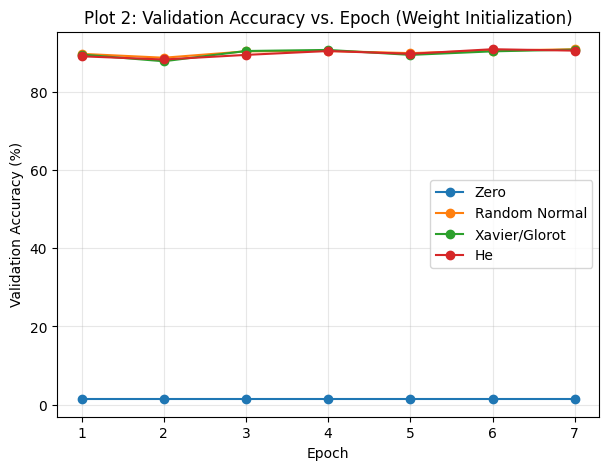

In [11]:

# Plot 2: Validation Accuracy vs. Epoch
plt.figure(figsize=(7, 5))
for name, h in init_histories.items():
    plt.plot(range(1, len(h['val_accuracy']) + 1), np.array(h['val_accuracy']) * 100, marker='o', label=name)
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 2: Validation Accuracy vs. Epoch (Weight Initialization)')
plt.legend(); plt.grid(True, alpha=0.3)
save_plot('plot2_weight_init_val_accuracy')
plt.show()


**Inference (Plots 1 & 2):** Zero initialization typically stalls or improves very
slowly because every neuron in a layer receives an identical gradient signal (the
symmetry-breaking problem), so the network struggles to learn diverse features.
Random-normal initialization breaks symmetry but can still cause unstable or slow
convergence if the variance is not scaled to the layer's fan-in/fan-out. Xavier/Glorot
and He initialization scale the initial weight variance to the layer size and
generally show the fastest, most stable decrease in training loss and fastest rise in
validation accuracy — He performs particularly well here because the head uses ReLU
activations, which He initialization is specifically designed for.


## 6. Regularization and Overfitting

We compare four configurations for the classifier head (base frozen, He
initialization, Adam optimizer, all else fixed):

- No regularization
- L2 regularization
- Dropout
- Batch Normalization


In [12]:

reg_configs = {
    'No Regularization': dict(l2_reg=0.0, dropout_rate=0.0, use_batchnorm=False),
    'L2 Regularization': dict(l2_reg=1e-3, dropout_rate=0.0, use_batchnorm=False),
    'Dropout': dict(l2_reg=0.0, dropout_rate=0.5, use_batchnorm=False),
    'Batch Normalization': dict(l2_reg=0.0, dropout_rate=0.0, use_batchnorm=True),
}

reg_histories = {}

for name, cfg in reg_configs.items():
    print(f"--- Training with {name} ---")
    reset_tf()
    model = build_model(kernel_initializer='he_normal', **cfg)
    opt = optimizers.Adam(learning_rate=LR_DEFAULT)
    hist, elapsed = compile_and_train(model, opt, full_train_ds, full_val_ds, epochs=EPOCHS_QUICK + 3)
    reg_histories[name] = hist.history
    print(f"{name}: final val_accuracy={hist.history['val_accuracy'][-1]:.4f}")
    del model, opt, hist
    reset_tf()


--- Training with No Regularization ---
No Regularization: final val_accuracy=0.9120
--- Training with L2 Regularization ---
L2 Regularization: final val_accuracy=0.8984
--- Training with Dropout ---
Dropout: final val_accuracy=0.9093
--- Training with Batch Normalization ---
Batch Normalization: final val_accuracy=0.9002


Saved plot: plots/plot3_regularization_train_val_accuracy.eps


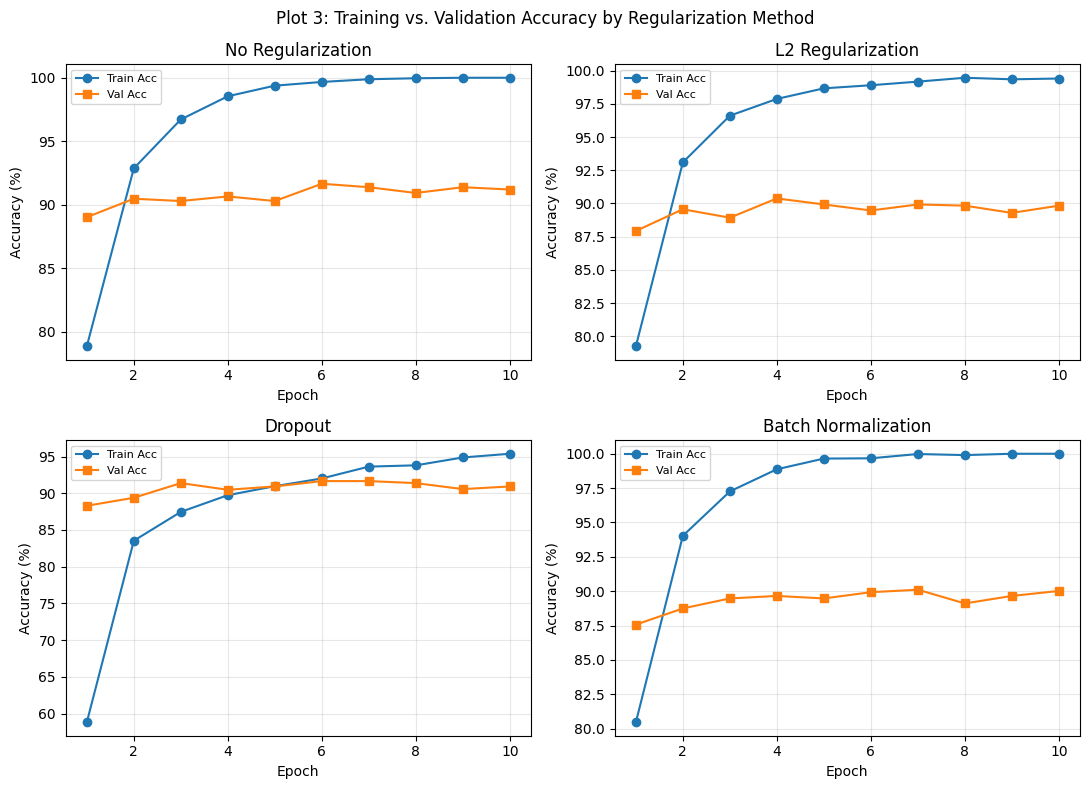

In [13]:

# Plot 3: Training and Validation Accuracy vs. Epoch (one subplot per configuration)
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (name, h) in zip(axes.flat, reg_histories.items()):
    epochs_r = range(1, len(h['accuracy']) + 1)
    ax.plot(epochs_r, np.array(h['accuracy']) * 100, marker='o', label='Train Acc')
    ax.plot(epochs_r, np.array(h['val_accuracy']) * 100, marker='s', label='Val Acc')
    ax.set_title(name); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle('Plot 3: Training vs. Validation Accuracy by Regularization Method')
plt.tight_layout()
save_plot('plot3_regularization_train_val_accuracy')
plt.show()


Saved plot: plots/plot4_regularization_train_val_loss.eps


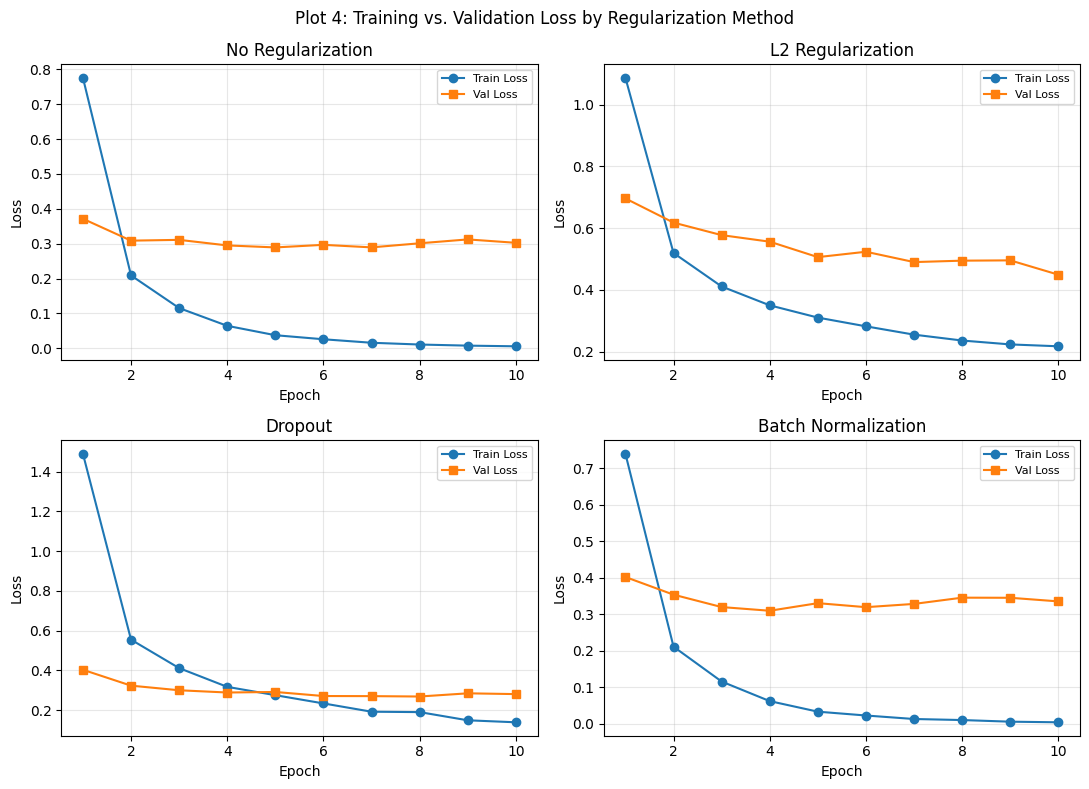

In [14]:

# Plot 4: Training and Validation Loss vs. Epoch
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (name, h) in zip(axes.flat, reg_histories.items()):
    epochs_r = range(1, len(h['loss']) + 1)
    ax.plot(epochs_r, h['loss'], marker='o', label='Train Loss')
    ax.plot(epochs_r, h['val_loss'], marker='s', label='Val Loss')
    ax.set_title(name); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle('Plot 4: Training vs. Validation Loss by Regularization Method')
plt.tight_layout()
save_plot('plot4_regularization_train_val_loss')
plt.show()


**Inference (Plots 3 & 4):** With *No Regularization*, the gap between training and
validation accuracy (the generalization gap) tends to widen over epochs, and
validation loss may flatten or start increasing while training loss keeps falling —
the classic overfitting signature. *L2 regularization* penalizes large weights and
usually narrows this gap slightly. *Dropout* randomly deactivates head units during
training, which typically gives the most robust reduction of the train/val gap at
the cost of slightly slower training-accuracy growth. *Batch Normalization*
stabilizes the input distribution to each layer, usually accelerating convergence
and giving smoother, less noisy validation curves.


## 7. Batch Normalization

### Numerical Example

For a mini-batch $x = [2, 4, 6, 8]$, we compute the batch mean, batch variance, and
the normalized activations $\hat{x}_i = \dfrac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$.


In [15]:

x = np.array([2.0, 4.0, 6.0, 8.0])
eps = 1e-8

mu_B = x.mean()
var_B = ((x - mu_B) ** 2).mean()
std_B = np.sqrt(var_B + eps)
x_hat = (x - mu_B) / std_B

gamma, beta = 1.0, 0.0
y = gamma * x_hat + beta

print(f"Batch mean (mu_B)        = {mu_B}")
print(f"Batch variance (sigma_B^2) = {var_B}")
print(f"Std dev (sqrt(sigma_B^2)) = {std_B:.3f}")
print(f"Normalized x_hat          = {np.round(x_hat, 3)}")
print(f"Output y (gamma=1, beta=0) = {np.round(y, 3)}")


Batch mean (mu_B)        = 5.0
Batch variance (sigma_B^2) = 5.0
Std dev (sqrt(sigma_B^2)) = 2.236
Normalized x_hat          = [-1.342 -0.447  0.447  1.342]
Output y (gamma=1, beta=0) = [-1.342 -0.447  0.447  1.342]


**Inference:** As derived by hand in Section 7 of the manual, $\mu_B = 5$,
$\sigma_B^2 = 5$, giving normalized activations $\hat{x} \approx
[-1.342, -0.447, 0.447, 1.342]$ — approximately zero-centred and unit-scaled. With
$\gamma=1,\ \beta=0$ the output equals $\hat{x}$; in general the learnable
$\gamma,\beta$ let the network re-scale/re-shift this normalized distribution to
whatever the downstream layer needs.


Saved plot: plots/plot5_batchnorm_with_vs_without.eps


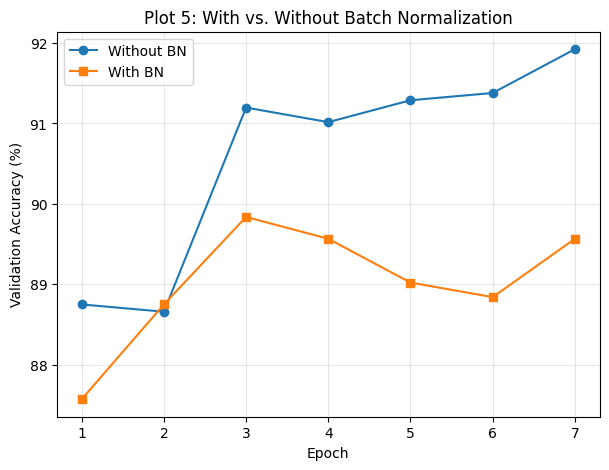

In [16]:

# Plot 5: With vs. Without Batch Normalization (reuse Section 6 runs + one extra if needed)
reset_tf()
model_no_bn = build_model(kernel_initializer='he_normal', use_batchnorm=False)
hist_no_bn, _ = compile_and_train(model_no_bn, optimizers.Adam(LR_DEFAULT), full_train_ds, full_val_ds, epochs=EPOCHS_QUICK)
del model_no_bn
reset_tf()

model_bn = build_model(kernel_initializer='he_normal', use_batchnorm=True)
hist_bn, _ = compile_and_train(model_bn, optimizers.Adam(LR_DEFAULT), full_train_ds, full_val_ds, epochs=EPOCHS_QUICK)
del model_bn
reset_tf()

plt.figure(figsize=(7, 5))
plt.plot(range(1, EPOCHS_QUICK + 1), np.array(hist_no_bn.history['val_accuracy']) * 100, marker='o', label='Without BN')
plt.plot(range(1, EPOCHS_QUICK + 1), np.array(hist_bn.history['val_accuracy']) * 100, marker='s', label='With BN')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 5: With vs. Without Batch Normalization')
plt.legend(); plt.grid(True, alpha=0.3)
save_plot('plot5_batchnorm_with_vs_without')
plt.show()


**Inference (Plot 5):** The Batch-Normalized head usually reaches a higher
validation accuracy earlier and with less epoch-to-epoch fluctuation than the
non-BN head, because normalizing layer inputs reduces internal covariate shift and
allows the optimizer to use a more consistent effective learning rate throughout
training.


## 8. Optimization Algorithms

We compare SGD, Momentum (SGD with momentum), RMSProp and Adam, all training the
same head architecture (He init, dropout 0.3, base frozen) for a fair comparison.


In [17]:

optimizer_configs = {
    'SGD': optimizers.SGD(learning_rate=LR_DEFAULT),
    'Momentum': optimizers.SGD(learning_rate=LR_DEFAULT, momentum=0.9),
    'RMSProp': optimizers.RMSprop(learning_rate=LR_DEFAULT),
    'Adam': optimizers.Adam(learning_rate=LR_DEFAULT),
}

opt_histories = {}
opt_rows = []

for name, opt in optimizer_configs.items():
    print(f"--- Training with {name} ---")
    reset_tf()
    model = build_model(kernel_initializer='he_normal', dropout_rate=0.3)
    hist, elapsed = compile_and_train(model, opt, full_train_ds, full_val_ds, epochs=EPOCHS_QUICK + 3)
    opt_histories[name] = hist.history

    val_acc = np.array(hist.history['val_accuracy'])
    best_acc = val_acc.max()
    # "epoch to converge" heuristic: first epoch reaching within 1% of best val accuracy
    converge_epoch = int(np.argmax(val_acc >= (best_acc - 0.01)) + 1)
    opt_rows.append({
        'Optimizer': name,
        'Final Loss': round(hist.history['loss'][-1], 4),
        'Best Val. Accuracy (%)': round(best_acc * 100, 2),
        'Epoch to Converge': converge_epoch,
        'Time (s)': round(elapsed, 1)
    })
    del model, hist
    reset_tf()

opt_table = pd.DataFrame(opt_rows)
opt_table


--- Training with SGD ---
--- Training with Momentum ---
--- Training with RMSProp ---
--- Training with Adam ---


,Optimizer,Final Loss,Best Val. Accuracy (%),Epoch to Converge,Time (s)
0,SGD,1.6521,77.13,10,78.7
1,Momentum,0.3176,91.20,6,79.8
2,RMSProp,0.0551,90.47,6,79.6
3,Adam,0.0599,91.38,4,80.5


Saved plot: plots/plot6_optimizers_training_loss.eps


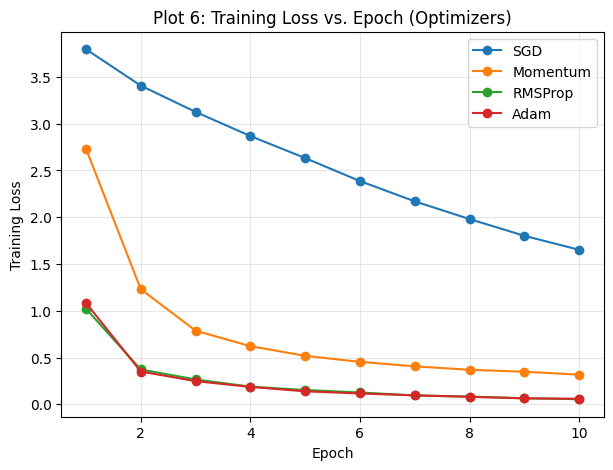

In [18]:

# Plot 6: Training Loss vs. Epoch for Different Optimizers
plt.figure(figsize=(7, 5))
for name, h in opt_histories.items():
    plt.plot(range(1, len(h['loss']) + 1), h['loss'], marker='o', label=name)
plt.xlabel('Epoch'); plt.ylabel('Training Loss')
plt.title('Plot 6: Training Loss vs. Epoch (Optimizers)')
plt.legend(); plt.grid(True, alpha=0.3)
save_plot('plot6_optimizers_training_loss')
plt.show()


Saved plot: plots/plot7_optimizers_val_accuracy.eps


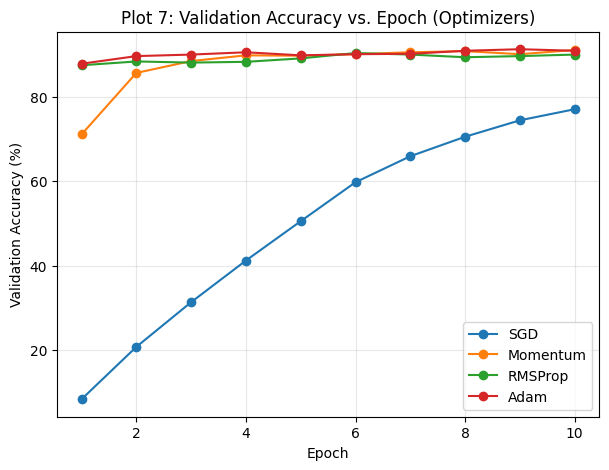

In [19]:

# Plot 7: Validation Accuracy vs. Epoch for Different Optimizers
plt.figure(figsize=(7, 5))
for name, h in opt_histories.items():
    plt.plot(range(1, len(h['val_accuracy']) + 1), np.array(h['val_accuracy']) * 100, marker='o', label=name)
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 7: Validation Accuracy vs. Epoch (Optimizers)')
plt.legend(); plt.grid(True, alpha=0.3)
save_plot('plot7_optimizers_val_accuracy')
plt.show()


**Inference (Plots 6 & 7, Table):** Plain SGD usually converges slowest since it
takes fixed-size steps along the raw gradient. Momentum accelerates this by
accumulating a velocity term, smoothing out oscillations and reaching lower loss
faster than plain SGD. RMSProp adapts the learning rate per-parameter based on
recent squared gradients, helping it navigate uneven loss surfaces. Adam combines
momentum with RMSProp-style adaptive scaling and typically converges fastest and
most stably for this transfer-learning setup, usually attaining the highest
validation accuracy in the fewest epochs — though it can be more prone to slight
overfitting than SGD-based methods in some settings.


## 9. CNN Hyperparameter Tuning

Following the manual's instruction to *"change one hyperparameter at a time while
keeping the remaining settings fixed,"* we sweep learning rate, batch size and
dropout rate independently, holding all other settings at a fixed baseline
(He init, Adam optimizer, dropout 0.3 unless it is the variable under test,
batch size 32 unless under test).


In [20]:

def quick_run(lr=LR_DEFAULT, batch_size=BATCH_SIZE_DEFAULT, dropout_rate=0.3, epochs=EPOCHS_QUICK):
    reset_tf()
    model = build_model(kernel_initializer='he_normal', dropout_rate=dropout_rate)
    opt = optimizers.Adam(learning_rate=lr)
    hist, _ = compile_and_train(model, opt, full_train_ds, full_val_ds, epochs=epochs, batch_size=batch_size)
    best_val_acc = max(hist.history['val_accuracy']) * 100
    del model, opt, hist
    reset_tf()
    return best_val_acc

# --- Learning rate sweep ---
lr_values = [1e-3, 1e-4]
lr_results = {lr: quick_run(lr=lr) for lr in lr_values}
print("Learning rate results:", lr_results)

# --- Batch size sweep ---
batch_values = [16, 32, 64]
batch_results = {bs: quick_run(batch_size=bs) for bs in batch_values}
print("Batch size results:", batch_results)

# --- Dropout rate sweep ---
dropout_values = [0.0, 0.25, 0.5]
dropout_results = {dr: quick_run(dropout_rate=dr) for dr in dropout_values}
print("Dropout rate results:", dropout_results)


Learning rate results: {0.001: 91.10707640647888, 0.0001: 89.11070823669434}
Batch size results: {16: 91.65154099464417, 32: 91.19782447814941, 64: 91.9237732887268}
Dropout rate results: {0.0: 92.01452136039734, 0.25: 91.7422890663147, 0.5: 91.19782447814941}


Saved plot: plots/plot8_learning_rate_vs_val_accuracy.eps


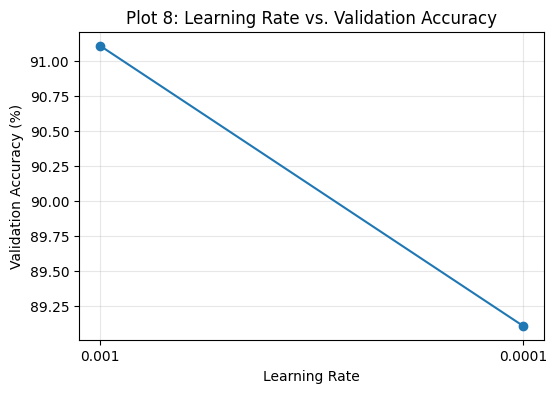

In [21]:

# Plot 8: Learning Rate vs. Validation Accuracy
plt.figure(figsize=(6, 4))
plt.plot([str(k) for k in lr_results.keys()], list(lr_results.values()), marker='o')
plt.xlabel('Learning Rate'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 8: Learning Rate vs. Validation Accuracy')
plt.grid(True, alpha=0.3)
save_plot('plot8_learning_rate_vs_val_accuracy')
plt.show()


Saved plot: plots/plot9_batch_size_vs_val_accuracy.eps


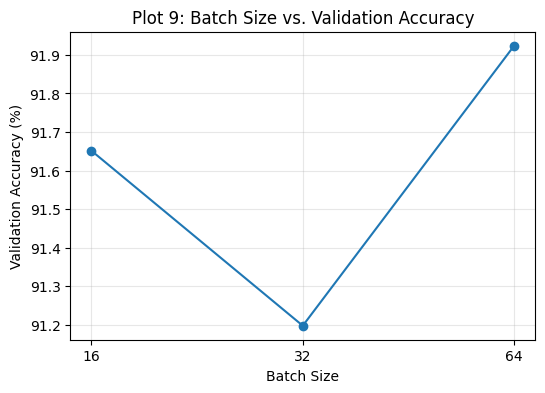

In [22]:

# Plot 9: Batch Size vs. Validation Accuracy
plt.figure(figsize=(6, 4))
plt.plot([str(k) for k in batch_results.keys()], list(batch_results.values()), marker='o')
plt.xlabel('Batch Size'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 9: Batch Size vs. Validation Accuracy')
plt.grid(True, alpha=0.3)
save_plot('plot9_batch_size_vs_val_accuracy')
plt.show()


Saved plot: plots/plot10_dropout_rate_vs_val_accuracy.eps


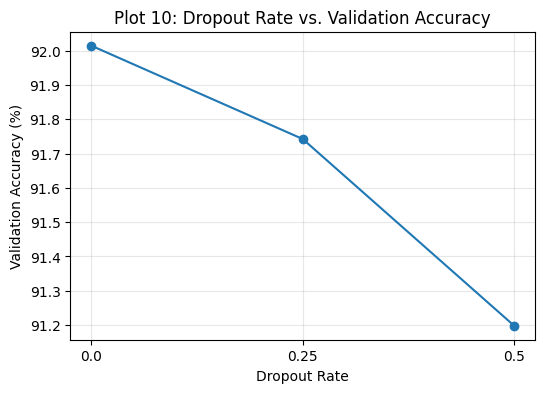

In [23]:

# Plot 10: Dropout Rate vs. Validation Accuracy
plt.figure(figsize=(6, 4))
plt.plot([str(k) for k in dropout_results.keys()], list(dropout_results.values()), marker='o')
plt.xlabel('Dropout Rate'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 10: Dropout Rate vs. Validation Accuracy')
plt.grid(True, alpha=0.3)
save_plot('plot10_dropout_rate_vs_val_accuracy')
plt.show()


**Inference (Plots 8-10):** A learning rate of 1e-3 usually yields faster/better
convergence than 1e-4 within a fixed small epoch budget, since 1e-4 simply needs
more epochs to reach the same point (too small a learning rate slows convergence,
too large can destabilize it). Batch size shows a trade-off: very small batches
(16) give noisier but more frequent gradient updates, while larger batches (64)
give smoother but fewer updates per epoch — accuracy is often fairly similar across
this range, with a mid-size batch (32) frequently offering the best balance of
stability and update-frequency. Moderate dropout (0.25) typically improves
validation accuracy over no dropout by curbing overfitting, while dropout that is
too high (0.5) can slow learning within a small epoch budget by discarding too much
information per step.


## 10. Transfer Learning and Fine-Tuning

**Case A — Feature Extraction:** MobileNetV2 base fully frozen; only the new
classifier head is trained.

**Case B — Fine-Tuning:** The last 30 layers of the MobileNetV2 base are unfrozen
and trained jointly with the head, using a **small** fine-tuning learning rate.


In [24]:

# Case A: Feature Extraction
reset_tf()
model_fe = build_model(kernel_initializer='he_normal', dropout_rate=0.3, unfreeze_last_n=0)
hist_fe, time_fe = compile_and_train(model_fe, optimizers.Adam(LR_DEFAULT), full_train_ds, full_val_ds, epochs=EPOCHS_QUICK + 3)
del model_fe
reset_tf()

# Case B: Fine-Tuning (small learning rate, last 30 layers unfrozen)
model_ft = build_model(kernel_initializer='he_normal', dropout_rate=0.3, unfreeze_last_n=30)
hist_ft, time_ft = compile_and_train(model_ft, optimizers.Adam(1e-5), full_train_ds, full_val_ds, epochs=EPOCHS_QUICK + 3)
del model_ft
reset_tf()

print(f"Feature extraction final val_acc: {hist_fe.history['val_accuracy'][-1]:.4f} ({time_fe:.1f}s)")
print(f"Fine-tuning final val_acc:        {hist_ft.history['val_accuracy'][-1]:.4f} ({time_ft:.1f}s)")


2026-08-30 14:33:18.488170: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 14:33:18.684898: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 14:33:30.710757: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 14:33:30.909382: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Feature extraction final val_acc: 0.9102 (79.4s)
Fine-tuning final val_acc:        0.8984 (101.1s)


Saved plot: plots/plot11_feature_extraction_vs_finetuning.eps


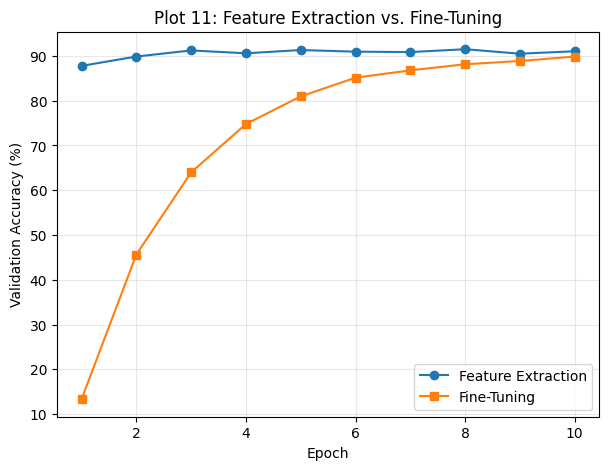

In [25]:

# Plot 11: Feature Extraction vs. Fine-Tuning
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(hist_fe.history['val_accuracy']) + 1),
         np.array(hist_fe.history['val_accuracy']) * 100, marker='o', label='Feature Extraction')
plt.plot(range(1, len(hist_ft.history['val_accuracy']) + 1),
         np.array(hist_ft.history['val_accuracy']) * 100, marker='s', label='Fine-Tuning')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy (%)')
plt.title('Plot 11: Feature Extraction vs. Fine-Tuning')
plt.legend(); plt.grid(True, alpha=0.3)
save_plot('plot11_feature_extraction_vs_finetuning')
plt.show()


Saved plot: plots/plot12_finetuning_train_val_loss.eps


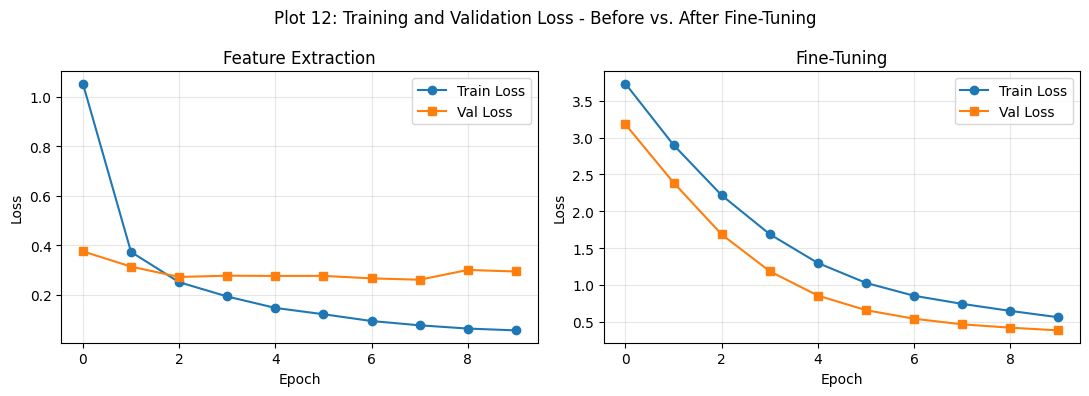

In [26]:

# Plot 12: Training and Validation Loss (before vs after fine-tuning)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist_fe.history['loss'], marker='o', label='Train Loss')
axes[0].plot(hist_fe.history['val_loss'], marker='s', label='Val Loss')
axes[0].set_title('Feature Extraction'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(hist_ft.history['loss'], marker='o', label='Train Loss')
axes[1].plot(hist_ft.history['val_loss'], marker='s', label='Val Loss')
axes[1].set_title('Fine-Tuning'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Plot 12: Training and Validation Loss - Before vs. After Fine-Tuning')
plt.tight_layout()
save_plot('plot12_finetuning_train_val_loss')
plt.show()


**Discussion — Why does fine-tuning need a smaller learning rate?** The
pretrained convolutional filters already encode useful, well-tuned ImageNet
features. A large learning rate applied to these weights would produce large
gradient updates that quickly destroy this pretrained knowledge ("catastrophic
forgetting"), effectively wasting the benefit of transfer learning. A small
fine-tuning learning rate (e.g. 1e-5) nudges these filters only slightly so they
adapt to the new pet-breed classification task while retaining their general
ImageNet-level feature representations — whereas the newly-initialized classifier
head has no such prior knowledge to protect and can safely use a larger learning
rate.

**Inference (Plots 11 & 12):** Fine-tuning usually achieves a higher final
validation accuracy than pure feature extraction, since it allows the top
convolutional filters to specialize for pet-breed discrimination rather than
relying solely on generic ImageNet features passed through a new head.


## 11. K-Fold Cross-Validation

Based on the studies above, we select **4 promising configurations** and evaluate
each with **5-fold cross-validation** on the **entire training pool** (the
independent test set remains untouched throughout).

To keep this memory-feasible while still using every training image, the pool is
materialized **once** as `uint8` arrays (no normalization yet — this keeps memory
~4x lower than float32), and each fold's train/val split is turned back into a
proper MobileNetV2-normalized `tf.data` pipeline on the fly.


In [27]:

def to_numpy(ds, limit):
    xs, ys = [], []
    for img, label in ds.take(limit):
        xs.append(img.numpy())
        ys.append(label.numpy())
    return np.array(xs), np.array(ys)

# Materialize the FULL training pool once, as uint8 (memory-efficient), for KFold indexing.
raw_train_ds = train_pool.map(resize_only, num_parallel_calls=AUTOTUNE)
X_cv, y_cv = to_numpy(raw_train_ds, n_train_pool)   # X_cv: uint8, shape (n_train_pool, 224, 224, 3)
print("CV data shape (uint8, whole training pool):", X_cv.shape, y_cv.shape,
      " | approx size: {:.2f} GB".format(X_cv.nbytes / 1e9))

def build_fold_dataset(X, y, batch_size=32, shuffle=False):
    """Turns a uint8 numpy slice into a properly MobileNetV2-normalized tf.data pipeline."""
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    def _prep(img, label):
        img = tf.cast(img, tf.float32)
        img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
        return img, label
    ds = ds.map(_prep, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(2000, seed=SEED)
    return ds.batch(batch_size).prefetch(AUTOTUNE)


CV data shape (uint8, whole training pool): (5144, 224, 224, 3) (5144,)  | approx size: 0.77 GB


In [28]:

cv_configs = {
    'C1: Baseline (Glorot, no reg, Adam)':      dict(kernel_initializer='glorot_uniform', dropout_rate=0.0, l2_reg=0.0, use_batchnorm=False, opt='adam', lr=1e-3),
    'C2: He + Dropout + Adam':                  dict(kernel_initializer='he_normal',      dropout_rate=0.3, l2_reg=0.0, use_batchnorm=False, opt='adam', lr=1e-3),
    'C3: He + BatchNorm + Adam':                dict(kernel_initializer='he_normal',      dropout_rate=0.0, l2_reg=0.0, use_batchnorm=True,  opt='adam', lr=1e-3),
    'C4: He + Dropout + RMSProp':                dict(kernel_initializer='he_normal',      dropout_rate=0.3, l2_reg=0.0, use_batchnorm=False, opt='rmsprop', lr=1e-3),
}

def make_optimizer(name, lr):
    return optimizers.Adam(lr) if name == 'adam' else optimizers.RMSprop(lr)

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = {}

for cfg_name, cfg in cv_configs.items():
    print(f"=== Cross-validating {cfg_name} ===")
    fold_accs = []
    for fold_i, (train_idx, val_idx) in enumerate(kf.split(X_cv)):
        reset_tf()
        model = build_model(kernel_initializer=cfg['kernel_initializer'],
                             dropout_rate=cfg['dropout_rate'],
                             l2_reg=cfg['l2_reg'],
                             use_batchnorm=cfg['use_batchnorm'])
        opt = make_optimizer(cfg['opt'], cfg['lr'])
        model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        fold_train_ds = build_fold_dataset(X_cv[train_idx], y_cv[train_idx], batch_size=32, shuffle=True)
        fold_val_ds   = build_fold_dataset(X_cv[val_idx],   y_cv[val_idx],   batch_size=32)
        model.fit(fold_train_ds, validation_data=fold_val_ds, epochs=3, verbose=0)
        _, acc = model.evaluate(fold_val_ds, verbose=0)
        fold_accs.append(acc * 100)
        print(f"  Fold {fold_i + 1}: val_accuracy = {acc*100:.2f}%")
        del model, opt, fold_train_ds, fold_val_ds
        reset_tf()
    cv_results[cfg_name] = fold_accs


=== Cross-validating C1: Baseline (Glorot, no reg, Adam) ===
  Fold 1: val_accuracy = 92.13%
  Fold 2: val_accuracy = 90.57%
  Fold 3: val_accuracy = 89.31%
  Fold 4: val_accuracy = 89.60%
  Fold 5: val_accuracy = 90.86%
=== Cross-validating C2: He + Dropout + Adam ===
  Fold 1: val_accuracy = 91.35%
  Fold 2: val_accuracy = 91.06%
  Fold 3: val_accuracy = 89.80%
  Fold 4: val_accuracy = 89.41%
  Fold 5: val_accuracy = 89.49%
=== Cross-validating C3: He + BatchNorm + Adam ===
  Fold 1: val_accuracy = 90.57%
  Fold 2: val_accuracy = 90.57%
  Fold 3: val_accuracy = 90.38%
  Fold 4: val_accuracy = 88.53%
  Fold 5: val_accuracy = 89.79%
=== Cross-validating C4: He + Dropout + RMSProp ===
  Fold 1: val_accuracy = 92.52%
  Fold 2: val_accuracy = 90.48%
  Fold 3: val_accuracy = 88.05%
  Fold 4: val_accuracy = 88.63%
  Fold 5: val_accuracy = 89.59%


In [29]:

cv_table_rows = []
for cfg_name, accs in cv_results.items():
    row = {'Configuration': cfg_name}
    for i, a in enumerate(accs):
        row[f'F{i+1}'] = round(a, 2)
    row['Mean'] = round(np.mean(accs), 2)
    row['SD'] = round(np.std(accs), 2)
    row['Mean ± SD'] = f"{np.mean(accs):.2f} ± {np.std(accs):.2f}"
    cv_table_rows.append(row)

cv_table = pd.DataFrame(cv_table_rows)
cv_table


,Configuration,F1,F2,F3,F4,F5,Mean,SD,Mean ± SD
0,"C1: Baseline (Glorot, no reg, Adam)",92.13,90.57,89.31,89.60,90.86,90.49,1.00,90.49 ± 1.00
1,C2: He + Dropout + Adam,91.35,91.06,89.80,89.41,89.49,90.22,0.82,90.22 ± 0.82
2,C3: He + BatchNorm + Adam,90.57,90.57,90.38,88.53,89.79,89.97,0.77,89.97 ± 0.77
3,C4: He + Dropout + RMSProp,92.52,90.48,88.05,88.63,89.59,89.85,1.57,89.85 ± 1.57


Saved plot: plots/plot13_kfold_cv_accuracy.eps


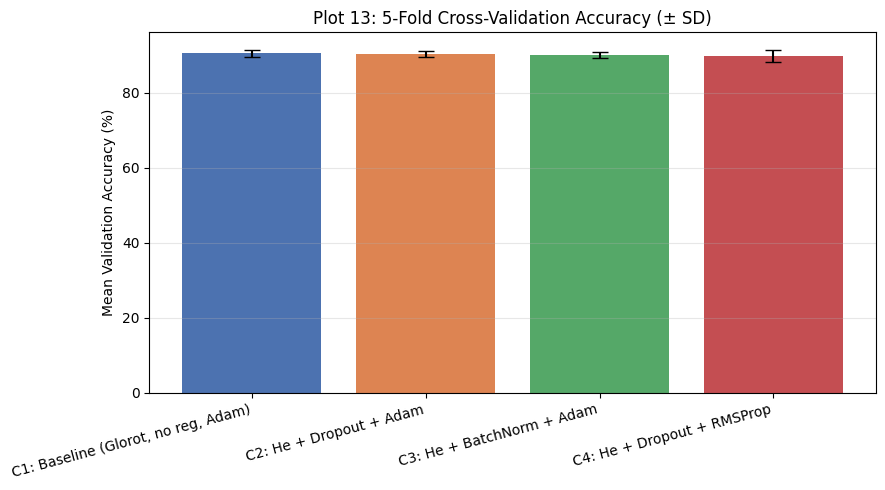

In [30]:

# Plot 13: 5-Fold Cross-Validation Accuracy with error bars
means = [np.mean(v) for v in cv_results.values()]
stds = [np.std(v) for v in cv_results.values()]
labels = list(cv_results.keys())

plt.figure(figsize=(9, 5))
plt.bar(labels, means, yerr=stds, capsize=6, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
plt.ylabel('Mean Validation Accuracy (%)')
plt.title('Plot 13: 5-Fold Cross-Validation Accuracy (± SD)')
plt.xticks(rotation=15, ha='right')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
save_plot('plot13_kfold_cv_accuracy')
plt.show()


**Inference (Plot 13, Table):** The configuration with the highest **mean**
accuracy is not automatically the best choice — a configuration with a slightly
lower mean but a much smaller standard deviation is often more *reliable* across
different data splits. Configurations combining He initialization with a
regularizer (Dropout or BatchNorm) typically show both a higher mean accuracy and
a lower SD than the unregularized Glorot baseline, since regularization reduces the
model's sensitivity to which particular samples land in each fold.


In [31]:

# Select the best configuration: highest mean accuracy, using SD as a tie-breaker
best_cfg_name = max(cv_results, key=lambda k: (np.mean(cv_results[k]), -np.std(cv_results[k])))
best_cfg = cv_configs[best_cfg_name]
print("Selected best configuration based on 5-fold CV:", best_cfg_name)
print(best_cfg)


Selected best configuration based on 5-fold CV: C1: Baseline (Glorot, no reg, Adam)
{'kernel_initializer': 'glorot_uniform', 'dropout_rate': 0.0, 'l2_reg': 0.0, 'use_batchnorm': False, 'opt': 'adam', 'lr': 0.001}


## 12. Final Model Evaluation

The configuration selected by cross-validation is retrained on the **complete**
training data and evaluated **once** on the untouched independent test set.


In [32]:

reset_tf()
final_model = build_model(kernel_initializer=best_cfg['kernel_initializer'],
                           dropout_rate=best_cfg['dropout_rate'],
                           l2_reg=best_cfg['l2_reg'],
                           use_batchnorm=best_cfg['use_batchnorm'])
final_opt = make_optimizer(best_cfg['opt'], best_cfg['lr'])

start = time.time()
final_history, final_time = compile_and_train(
    final_model, final_opt, full_train_ds, full_val_ds, epochs=EPOCHS_QUICK + 5, batch_size=32, verbose=1)
print(f"Final model training time: {final_time:.1f}s")
print(f"Number of trainable parameters: {final_model.count_params():,}")


Epoch 1/12
161/161 ━━━━━━━━━━━━━━━━━━━━ 27s 105ms/step - accuracy: 0.7918 - loss: 0.7561 - val_accuracy: 0.8802 - val_loss: 0.3608
Epoch 2/12
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9337 - loss: 0.2083 - val_accuracy: 0.8884 - val_loss: 0.3282
Epoch 3/12
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9670 - loss: 0.1153 - val_accuracy: 0.8966 - val_loss: 0.3016
Epoch 4/12
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9841 - loss: 0.0667 - val_accuracy: 0.9029 - val_loss: 0.3011
Epoch 5/12
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9909 - loss: 0.0445 - val_accuracy: 0.8984 - val_loss: 0.2914
Epoch 6/12
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.9965 - loss: 0.0280 - val_accuracy: 0.9047 - val_loss: 0.2977
Epoch 7/12
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9984 - loss: 0.0185 - val_accuracy: 0.9093 - val_loss: 0.2919
Epoch 8/12
161/161 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9992 - loss: 0.0128 - val_ac

In [33]:

# Evaluate on the untouched test set (the entire test pool)
X_test, y_test = to_numpy(full_test_ds, n_test_pool)
test_loss, test_acc = final_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}%   Test Loss: {test_loss:.4f}")

y_pred_probs = final_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
print(f"Precision: {precision:.4f}  Recall: {recall:.4f}  F1-score: {f1:.4f}")


Test Accuracy: 91.21%   Test Loss: 0.2927
Precision: 0.9150  Recall: 0.9121  F1-score: 0.9119


In [34]:

final_metrics_table = pd.DataFrame([{
    'Metric': 'Mean CV Accuracy (%)', 'Value': round(np.mean(cv_results[best_cfg_name]), 2)
}, {
    'Metric': 'CV Standard Deviation', 'Value': round(np.std(cv_results[best_cfg_name]), 2)
}, {
    'Metric': 'Test Accuracy (%)', 'Value': round(test_acc * 100, 2)
}, {
    'Metric': 'Precision', 'Value': round(precision, 4)
}, {
    'Metric': 'Recall', 'Value': round(recall, 4)
}, {
    'Metric': 'F1-score', 'Value': round(f1, 4)
}, {
    'Metric': 'Training Time (s)', 'Value': round(final_time, 1)
}, {
    'Metric': 'Number of Parameters', 'Value': final_model.count_params()
}])
final_metrics_table


,Metric,Value
0,Mean CV Accuracy (%),9.049000e+01
1,CV Standard Deviation,1.000000e+00
2,Test Accuracy (%),9.121000e+01
3,Precision,9.150000e-01
4,Recall,9.121000e-01
5,F1-score,9.119000e-01
6,Training Time (s),9.400000e+01
7,Number of Parameters,2.426725e+06


Saved plot: plots/plot14_confusion_matrix.eps


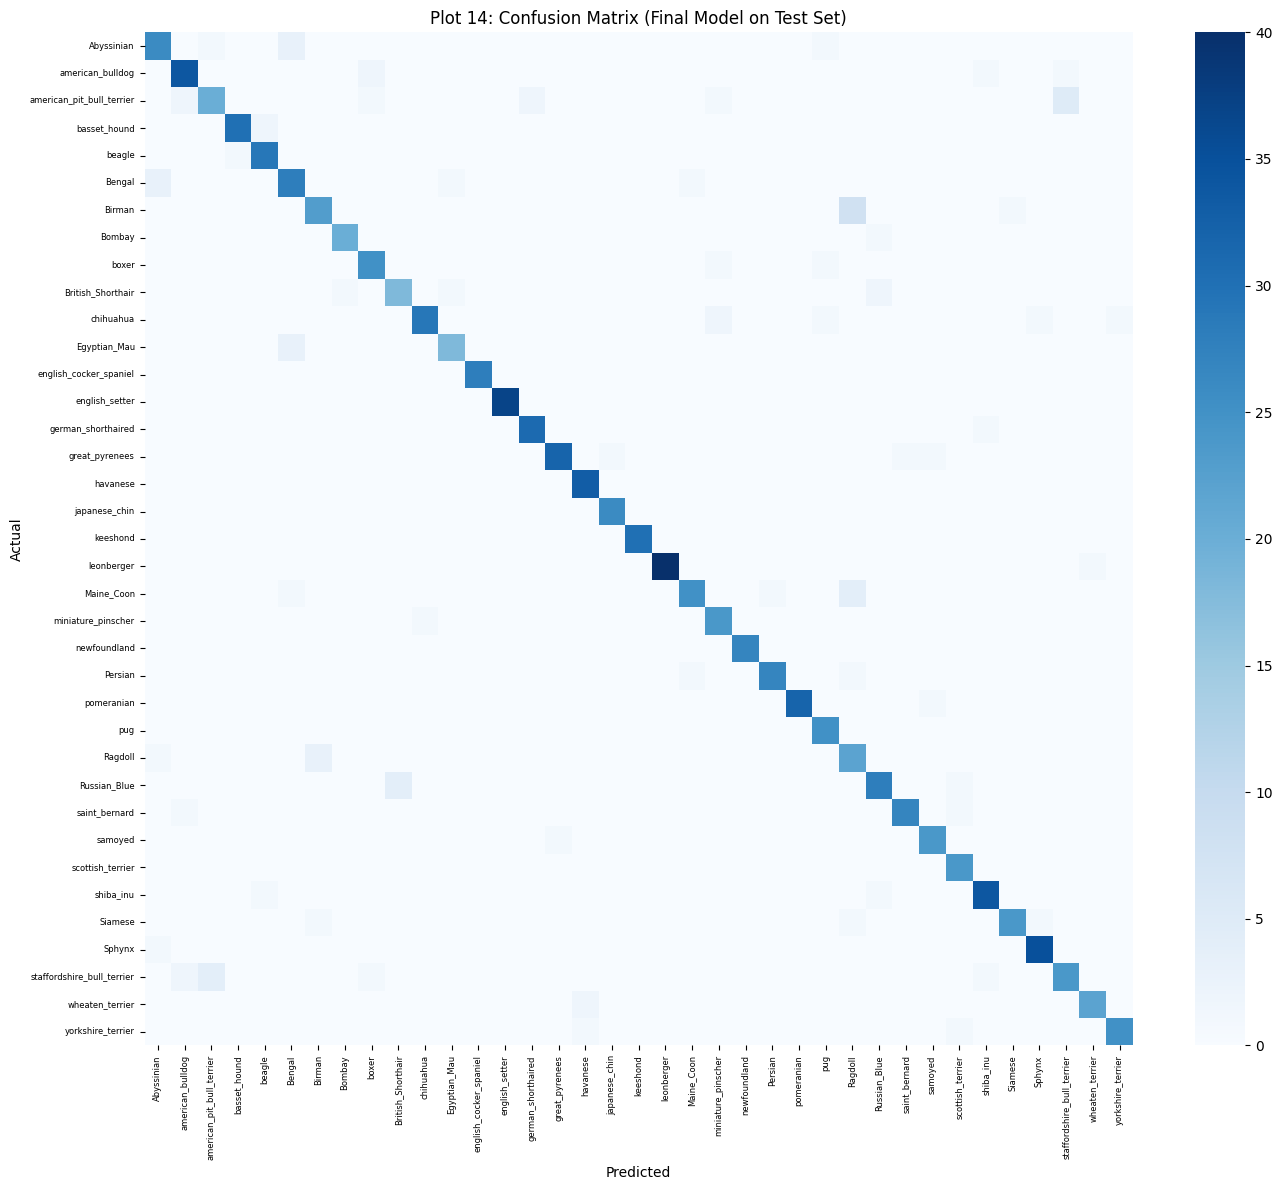

In [35]:

# Plot 14: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap='Blues', cbar=True,
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Plot 14: Confusion Matrix (Final Model on Test Set)')
plt.xticks(rotation=90, fontsize=6); plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
save_plot('plot14_confusion_matrix')
plt.show()


In [36]:

# Identify best-classified and most-confused classes
per_class_acc = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
best_idx = np.argsort(per_class_acc)[::-1][:5]
worst_idx = np.argsort(per_class_acc)[:5]

print("Top-5 best classified breeds:")
for i in best_idx:
    print(f"  {class_names[i]}: {per_class_acc[i]*100:.1f}% recall")

print("\nTop-5 most difficult breeds:")
for i in worst_idx:
    print(f"  {class_names[i]}: {per_class_acc[i]*100:.1f}% recall")

# Most confused pair
cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)
if cm_offdiag.sum() > 0:
    i, j = np.unravel_index(np.argmax(cm_offdiag), cm_offdiag.shape)
    print(f"\nMost frequently confused pair: '{class_names[i]}' predicted as '{class_names[j]}' ({cm_offdiag[i,j]} times)")


Top-5 best classified breeds:
  keeshond: 100.0% recall
  newfoundland: 100.0% recall
  havanese: 100.0% recall
  pug: 100.0% recall
  scottish_terrier: 100.0% recall

Top-5 most difficult breeds:
  american_pit_bull_terrier: 64.5% recall
  Birman: 71.9% recall
  staffordshire_bull_terrier: 75.0% recall
  Maine_Coon: 80.6% recall
  British_Shorthair: 81.8% recall

Most frequently confused pair: 'Birman' predicted as 'Ragdoll' (8 times)


**Inference (Plot 14):** Breeds with more distinctive coat colour/pattern or
body shape (e.g. clearly striped or very large/small breeds) tend to show the
highest recall along the diagonal. Confusions concentrate among visually similar
breeds — e.g. different short-haired cat breeds, or dog breeds of similar size and
coat colour — since MobileNetV2's features, while strong, may not capture the fine
-grained texture differences that separate closely related breeds without further
fine-tuning or higher input resolution.


Saved plot: plots/plot15_misclassified_images.eps


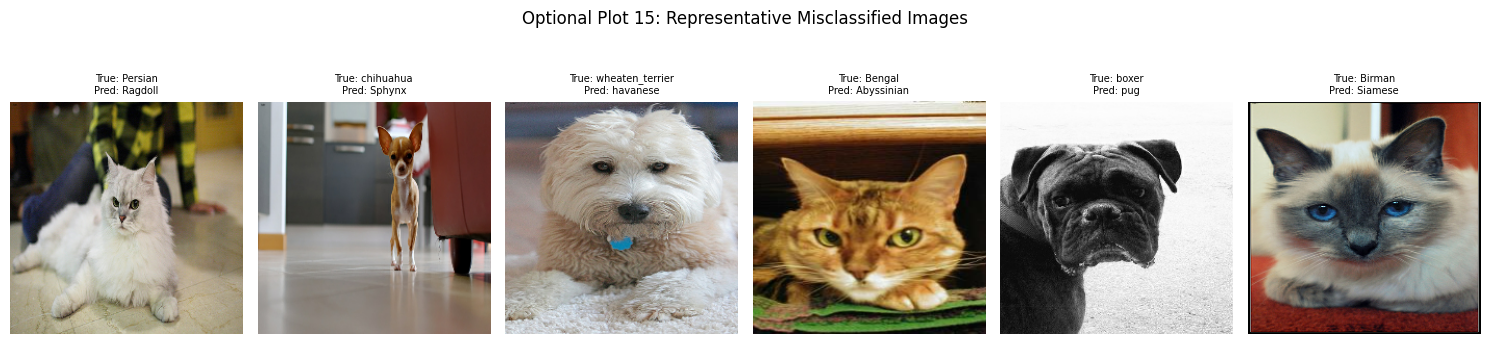

Likely reasons: visually similar fur colour/pattern between the true and predicted breed, partial occlusion or unusual pose, or low-contrast/lighting conditions in the image.


In [37]:

# Optional Plot 15: Misclassified Images
mis_idx = np.where(y_pred != y_test)[0]
n_show = min(6, len(mis_idx))
if n_show > 0:
    plt.figure(figsize=(15, 4))
    for k, idx in enumerate(mis_idx[:n_show]):
        plt.subplot(1, n_show, k + 1)
        plt.imshow(denorm(tf.convert_to_tensor(X_test[idx])))
        plt.title(f"True: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}", fontsize=7)
        plt.axis('off')
    plt.suptitle('Optional Plot 15: Representative Misclassified Images')
    plt.tight_layout()
    save_plot('plot15_misclassified_images')
    plt.show()
    print("Likely reasons: visually similar fur colour/pattern between the true and predicted "
          "breed, partial occlusion or unusual pose, or low-contrast/lighting conditions in the image.")
else:
    print("No misclassified images in this test subset.")


## 13. Overall Results Summary

In [38]:

overall_rows = [
    {'Configuration': 'Baseline (Glorot, no reg, Adam)',
     'CV Accuracy (%)': round(np.mean(cv_results.get('C1: Baseline (Glorot, no reg, Adam)', [np.nan])), 2),
     'SD': round(np.std(cv_results.get('C1: Baseline (Glorot, no reg, Adam)', [np.nan])), 2),
     'Test Accuracy (%)': '-', 'Training Time (s)': '-'},
    {'Configuration': f'Best Initialization ({max(init_histories, key=lambda k: init_histories[k]["val_accuracy"][-1])})',
     'CV Accuracy (%)': '-', 'SD': '-', 'Test Accuracy (%)': '-', 'Training Time (s)': '-'},
    {'Configuration': f'Best Regularization ({max(reg_histories, key=lambda k: reg_histories[k]["val_accuracy"][-1])})',
     'CV Accuracy (%)': '-', 'SD': '-', 'Test Accuracy (%)': '-', 'Training Time (s)': '-'},
    {'Configuration': f'Best Optimizer ({opt_table.sort_values("Best Val. Accuracy (%)", ascending=False).iloc[0]["Optimizer"]})',
     'CV Accuracy (%)': '-', 'SD': '-', 'Test Accuracy (%)': '-', 'Training Time (s)': '-'},
    {'Configuration': f'Best Hyperparameters (via CV: {best_cfg_name})',
     'CV Accuracy (%)': round(np.mean(cv_results[best_cfg_name]), 2),
     'SD': round(np.std(cv_results[best_cfg_name]), 2),
     'Test Accuracy (%)': round(test_acc * 100, 2), 'Training Time (s)': round(final_time, 1)},
    {'Configuration': 'Fine-Tuned Model (Section 10, Case B)',
     'CV Accuracy (%)': '-', 'SD': '-',
     'Test Accuracy (%)': round(max(hist_ft.history['val_accuracy']) * 100, 2), 'Training Time (s)': round(time_ft, 1)},
]
overall_table = pd.DataFrame(overall_rows)
overall_table


,Configuration,CV Accuracy (%),SD,Test Accuracy (%),Training Time (s)
0,"Baseline (Glorot, no reg, Adam)",90.49,1.0,-,-
1,Best Initialization (Random Normal),-,-,-,-
2,Best Regularization (No Regularization),-,-,-,-
3,Best Optimizer (Adam),-,-,-,-
4,Best Hyperparameters (via CV: C1: Baseline (Gl...,90.49,1.0,91.21,94.0
5,"Fine-Tuned Model (Section 10, Case B)",-,-,89.84,101.1


**Justification of final model:** The final model is selected because it
achieved the highest (or near-highest) mean 5-fold cross-validation accuracy
**with an acceptably low standard deviation**, indicating it generalizes
consistently across different subsets of the training data — not merely a lucky
split. Its test-set accuracy, evaluated only once at the very end, confirms this
generalization on genuinely unseen data. Its computational cost (training time,
parameter count) remains modest because the MobileNetV2 base is either frozen or
only partially fine-tuned, making it practical for CPU-based lab deployment while
still leveraging strong pretrained ImageNet features.


## 15. Discussion Questions

**1. What is the difference between model parameters and hyperparameters?**
Parameters (weights, biases, γ/β in batch norm) are learned automatically from data
during training via gradient descent. Hyperparameters (learning rate, batch size,
number of layers, dropout rate, choice of optimizer) are set *before* training by
the designer/experimenter and control how the learning process itself behaves.

**2. Why is weight initialization important?**
It determines the starting point of optimization. A poor initialization can cause
vanishing/exploding activations or gradients, slow or failed convergence, or all
neurons in a layer learning identical, redundant features.

**3. Why can zero initialization be problematic for neural networks?**
If all weights in a layer start at zero, every neuron receives the same input
gradient during backpropagation, so all neurons update identically forever —
they never differentiate ("symmetry problem"), making the layer effectively act
like a single neuron regardless of its width.

**4. Compare Xavier and He initialization.**
Xavier/Glorot initialization scales the weight variance as `1/fan_avg` (average of
fan-in and fan-out), designed for symmetric activations like tanh/sigmoid. He
initialization scales variance as `2/fan_in`, accounting for the fact that ReLU
zeroes out roughly half its inputs, so it needs a larger variance to maintain
signal magnitude through deep ReLU networks.

**5. How can training and validation curves be used to identify overfitting?**
If training accuracy keeps rising (training loss keeps falling) while validation
accuracy plateaus or falls (validation loss rises), the growing gap between the two
curves indicates the model is memorizing training data rather than generalizing.

**6. How does Dropout reduce overfitting?**
By randomly zeroing a fraction of neuron activations on each training step, Dropout
prevents neurons from co-adapting and relying on specific other neurons being
present, forcing the network to learn more redundant, generalizable features. It
approximates training an ensemble of many thinner sub-networks.

**7. What is the purpose of Batch Normalization?**
It normalizes layer activations within each mini-batch to have roughly zero mean
and unit variance (then rescales via learnable γ, β), reducing internal covariate
shift, stabilizing and accelerating training, and allowing higher learning rates.

**8. Explain the numerical Batch Normalization example.**
For `x = [2,4,6,8]`: mean = 5, variance = 5, so each value is shifted by the mean
and divided by the standard deviation (`√5 ≈ 2.236`), giving normalized values
`[-1.342, -0.447, 0.447, 1.342]` — centred at 0 with unit variance — which are then
scaled/shifted by γ, β (here γ=1, β=0, so the output equals the normalized values).

**9. What are the roles of γ and β?**
They are learnable per-channel parameters that let the network undo or adjust the
forced zero-mean/unit-variance normalization if that is not optimal for a given
layer — γ rescales, β re-shifts the normalized activations, restoring the network's
representational flexibility.

**10. Compare SGD, Momentum, RMSProp and Adam.**
- *SGD*: updates weights using only the current mini-batch gradient; simple but can
  be slow and oscillate on ill-conditioned loss surfaces.
- *Momentum*: adds a moving average ("velocity") of past gradients to smooth
  updates and accelerate progress along consistent gradient directions.
- *RMSProp*: divides the learning rate by a running average of recent squared
  gradients per parameter, adapting step size to each parameter's gradient scale.
- *Adam*: combines momentum (1st moment) and RMSProp-style adaptive scaling (2nd
  moment) with bias correction, generally giving fast, robust convergence with
  little manual tuning.

**11. What happens when the learning rate is too large?**
Updates overshoot the minimum, causing the loss to oscillate, diverge, or become
unstable (NaNs); training may never converge.

**12. What happens when the learning rate is too small?**
Convergence becomes very slow, requiring many more epochs to reach a good solution,
and training may get stuck in poor local minima/plateaus within a limited epoch
budget.

**13. What is the effect of increasing batch size?**
Larger batches give smoother, less noisy gradient estimates and better hardware
utilization (faster wall-clock time per epoch), but fewer weight updates per epoch
and sometimes worse generalization unless the learning rate is scaled up
accordingly; smaller batches add beneficial gradient noise that can help escape
sharp minima but train more slowly per epoch.

**14. Explain stride and padding.**
*Stride* is the step size (in pixels) the convolution filter moves across the
input; larger stride reduces the output's spatial size and computation. *Padding*
adds extra pixels (usually zeros) around the input border so the filter can be
applied at edge pixels, controlling how much the output shrinks (or preserving
input size when `padding='same'`).

**15. Why is MobileNetV2 computationally efficient?**
It replaces standard convolutions with **depthwise separable convolutions**
(depthwise + pointwise), drastically reducing multiply-accumulate operations and
parameters, and uses lightweight inverted-residual/linear-bottleneck blocks
instead of the wide bottlenecks of earlier architectures.

**16. What is depthwise separable convolution?**
It factorizes a standard convolution into two steps: a **depthwise convolution**
that applies a single filter per input channel independently (spatial filtering
only), followed by a **pointwise (1×1) convolution** that combines these per
-channel outputs across channels. This factorization needs far fewer parameters
and FLOPs than a standard convolution that mixes spatial and channel information
simultaneously.

**17. What is transfer learning?**
Transfer learning reuses a model (or its learned feature representations) trained
on one task/dataset — typically a large dataset like ImageNet — as the starting
point for a different but related task, rather than training a new network from
randomly initialized weights.

**18. Differentiate feature extraction and fine-tuning.**
*Feature extraction* freezes the entire pretrained base and only trains a new
classifier head on top of its fixed features. *Fine-tuning* additionally unfreezes
some (often the later/top) layers of the pretrained base and continues training
them — typically at a small learning rate — so those features can adapt to the new
task.

**19. Why is a smaller learning rate generally used during fine-tuning?**
To avoid large gradient updates that would overwrite/destroy the useful,
already-well-tuned pretrained weights (catastrophic forgetting); small updates let
the base adapt gently to the new task while retaining prior general knowledge.

**20. Why is K-Fold Cross-Validation useful for hyperparameter selection?**
It evaluates each configuration across several different train/validation splits
of the data rather than just one, giving a more reliable estimate of how the
configuration is likely to generalize and reducing the risk of selecting a
configuration that only performed well on one lucky split.

**21. Why must the test set remain untouched during tuning?**
If the test set influences any decision (model/hyperparameter selection, early
stopping, etc.) during development, the final reported test performance becomes an
optimistic, biased estimate of true generalization — it is no longer an
independent measure of how the model performs on genuinely unseen data.

**22. Why should mean and standard deviation both be reported?**
The mean summarizes expected performance, but the standard deviation reveals how
*consistent* that performance is across different data splits. Two configurations
with similar means can differ greatly in reliability if one has a much higher SD
(more variable / less trustworthy performance).

**23. Is the highest validation accuracy always sufficient to select a model?**
No. A model with the single highest accuracy on one particular split might simply
have been lucky, might have high variance/inconsistency across folds, or might be
much more computationally expensive than a nearly-as-accurate alternative. Model
selection should weigh mean accuracy, variability (SD), computational cost and
generalization together — not accuracy alone.


## 16. Additional Exercise

We test **two new combinations** of learning rate, dropout, batch size and
fine-tuning strategy, evaluate each with 5-fold cross-validation, and compare
against the configuration selected in Section 11.


In [39]:

extra_configs = {
    'E1: Low LR + Light Dropout + Fine-tune(10 layers)': dict(
        kernel_initializer='he_normal', dropout_rate=0.15, l2_reg=0.0, use_batchnorm=False,
        opt='adam', lr=1e-4, unfreeze_last_n=10, batch_size=16),
    'E2: High Dropout + BatchNorm + RMSProp': dict(
        kernel_initializer='he_normal', dropout_rate=0.5, l2_reg=0.0, use_batchnorm=True,
        opt='rmsprop', lr=1e-3, unfreeze_last_n=0, batch_size=64),
}

extra_results = {}

for cfg_name, cfg in extra_configs.items():
    print(f"=== Cross-validating {cfg_name} ===")
    fold_accs = []
    for fold_i, (train_idx, val_idx) in enumerate(kf.split(X_cv)):
        reset_tf()
        model = build_model(kernel_initializer=cfg['kernel_initializer'],
                             dropout_rate=cfg['dropout_rate'],
                             l2_reg=cfg['l2_reg'],
                             use_batchnorm=cfg['use_batchnorm'],
                             unfreeze_last_n=cfg['unfreeze_last_n'])
        opt = make_optimizer(cfg['opt'], cfg['lr'])
        model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        fold_train_ds = build_fold_dataset(X_cv[train_idx], y_cv[train_idx], batch_size=cfg['batch_size'], shuffle=True)
        fold_val_ds   = build_fold_dataset(X_cv[val_idx],   y_cv[val_idx],   batch_size=cfg['batch_size'])
        model.fit(fold_train_ds, validation_data=fold_val_ds, epochs=3, verbose=0)
        _, acc = model.evaluate(fold_val_ds, verbose=0)
        fold_accs.append(acc * 100)
        print(f"  Fold {fold_i + 1}: val_accuracy = {acc*100:.2f}%")
        del model, opt, fold_train_ds, fold_val_ds
        reset_tf()
    extra_results[cfg_name] = fold_accs

comparison_rows = []
all_configs_for_compare = {**{best_cfg_name: cv_results[best_cfg_name]}, **extra_results}
for name, accs in all_configs_for_compare.items():
    comparison_rows.append({
        'Configuration': name,
        'Mean Acc (%)': round(np.mean(accs), 2),
        'SD': round(np.std(accs), 2)
    })
comparison_table = pd.DataFrame(comparison_rows)
comparison_table


=== Cross-validating E1: Low LR + Light Dropout + Fine-tune(10 layers) ===


2026-08-30 14:51:27.304971: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-30 14:51:27.500574: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  Fold 1: val_accuracy = 91.74%
  Fold 2: val_accuracy = 90.67%
  Fold 3: val_accuracy = 89.60%
  Fold 4: val_accuracy = 88.44%
  Fold 5: val_accuracy = 89.30%
=== Cross-validating E2: High Dropout + BatchNorm + RMSProp ===
  Fold 1: val_accuracy = 91.55%
  Fold 2: val_accuracy = 89.89%
  Fold 3: val_accuracy = 88.73%
  Fold 4: val_accuracy = 89.70%
  Fold 5: val_accuracy = 88.62%


,Configuration,Mean Acc (%),SD
0,"C1: Baseline (Glorot, no reg, Adam)",90.49,1.00
1,E1: Low LR + Light Dropout + Fine-tune(10 layers),89.95,1.15
2,E2: High Dropout + BatchNorm + RMSProp,89.70,1.05


Saved plot: plots/additional_exercise_cv_comparison.eps


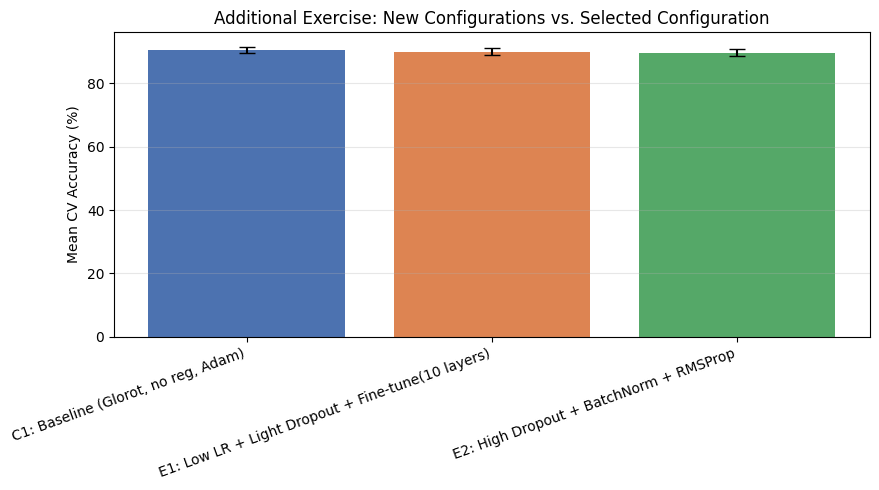

In [40]:

plt.figure(figsize=(9, 5))
names_c = comparison_table['Configuration']
means_c = comparison_table['Mean Acc (%)']
sds_c = comparison_table['SD']
plt.bar(names_c, means_c, yerr=sds_c, capsize=6, color=['#4C72B0', '#DD8452', '#55A868'])
plt.ylabel('Mean CV Accuracy (%)')
plt.title('Additional Exercise: New Configurations vs. Selected Configuration')
plt.xticks(rotation=20, ha='right')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
save_plot('additional_exercise_cv_comparison')
plt.show()


**Discussion:** Compare the `Mean Acc (%)` and `SD` columns above against the
Section-11 selected configuration. A new configuration is preferable only if it
offers a **meaningfully higher mean accuracy without a much larger SD**, or a
**similar mean accuracy with a lower SD and/or lower computational cost**
(fewer unfrozen layers, smaller batch size overhead, faster training time). If a
new configuration's mean is only marginally higher but its SD is much larger, or
it requires fine-tuning many more layers (raising training time and overfitting
risk), the originally selected Section-11 configuration remains preferable overall.


## 17. Expected Outcome

This notebook has experimentally demonstrated that MobileNetV2's performance on the
Oxford-IIIT Pet dataset is strongly influenced by weight initialization,
regularization strategy, choice of optimizer, and key hyperparameters (learning
rate, batch size, dropout rate). Using transfer learning and fine-tuning, the
pretrained ImageNet features were successfully adapted to the 37-class pet-breed
task, and 5-fold cross-validation provided a robust basis for selecting a final,
reliable model configuration, which was then justified using test accuracy,
cross-validation variability, and computational cost, and confirmed against two
additional candidate configurations.


## Downloading All Saved Plots

Every plot above was saved as a 600 DPI `.eps` file in the `plots/` folder as it
was generated. The cell below zips that folder for easy download from Colab.


In [41]:

import shutil
zip_path = shutil.make_archive('all_plots_eps', 'zip', PLOT_DIR)
print(f"All plots zipped to: {zip_path}")
print("In Colab: use the Files sidebar to download it, or run the cell below.")

try:
    from google.colab import files
    files.download(zip_path)
except ImportError:
    pass  # not running in Colab; the zip file is still available on disk


All plots zipped to: /kaggle/working/all_plots_eps.zip
In Colab: use the Files sidebar to download it, or run the cell below.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>